# Exploration des mesures Yélé

Visualisation du dataset nettoyé (`dataset_clean.csv`) produit par `prepare_data.py`,
avant de construire les modèles (détection d'anomalies, prédiction de qualité).

> Lancer d'abord : `python prepare_data.py`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('dataset_clean.csv', parse_dates=['timestamp'])
print(f'{len(df)} mesures')
df.head()

137 mesures


,uuid,timestamp,dl,ul,ping,jitter,operator,network_type,device_model,location,...,streaming_max_resolution,streaming_score,browsing_avg_load_ms,browsing_success_rate,browsing_pages_tested,browsing_score,hour,dayofweek,is_weekend,is_wifi
0,01KTMYNC0CG6CEBCKFAE32RWBR,2026-06-09 01:06:30.540000+00:00,50.21,7.45,316.65,26.87,Orange Burkina Faso,4G,SM-S9010,Inconnu,...,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0,0
1,01KTMYP9SBWQNCBNWCYXMACK89,2026-06-09 01:07:01.035000+00:00,59.27,8.77,294.44,27.20,Orange Burkina Faso,4G,SM-S9010,Inconnu,...,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0,0
2,01KTMYWRJ8MCGSAM3K640YJFWK,2026-06-09 01:10:32.776000+00:00,46.97,6.16,612.50,39.45,Orange Burkina Faso,Web Connection,CHROME,Inconnu,...,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0,0
3,01KTMYYMYNN7A1H5RZ6G443TSS,2026-06-09 01:11:34.613000+00:00,44.79,6.29,620.90,31.80,Orange Burkina Faso,Web Connection,CHROME,Inconnu,...,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0,0
4,01KTN021ZH2KX87M80SPB5BGQN,2026-06-09 01:30:54.833000+00:00,51.36,8.03,311.93,33.38,Orange Burkina Faso,4G,SM-S9010,"Ouagadougou, Burkina Faso",...,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0,0


In [2]:
# Statistiques descriptives des KPI
df[['dl', 'ul', 'ping', 'jitter']].describe().round(2)

,dl,ul,ping,jitter
count,137.00,137.00,137.00,137.00
mean,28.84,10.43,454.36,165.68
std,24.31,17.85,294.64,295.79
min,0.41,0.11,45.00,3.10
25%,8.35,4.02,296.90,29.88
50%,21.30,7.01,359.20,66.22
75%,47.16,9.87,501.88,180.25
max,96.62,143.12,2677.23,2682.36


## Distributions des débits et latences
Repérer les valeurs extrêmes et la forme des distributions (utile pour choisir les seuils d'anomalie).

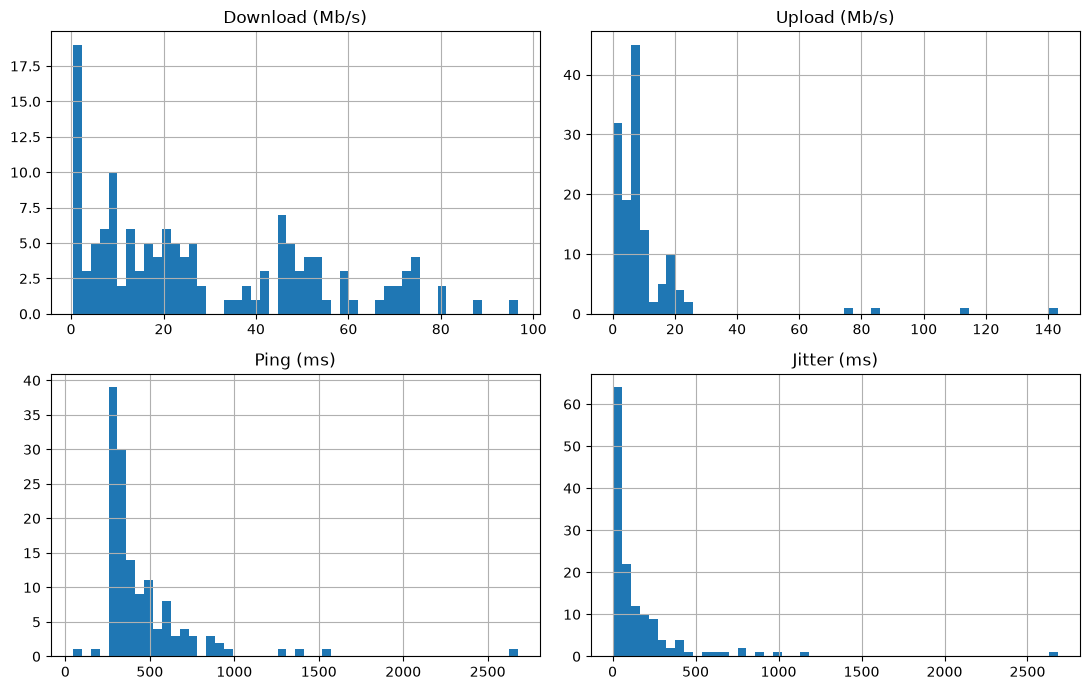

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col, title in zip(
    axes.ravel(),
    ['dl', 'ul', 'ping', 'jitter'],
    ['Download (Mb/s)', 'Upload (Mb/s)', 'Ping (ms)', 'Jitter (ms)'],
):
    df[col].dropna().hist(bins=50, ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()

## Répartition par opérateur et par technologie

In [4]:
print('Part WiFi vs mobile :')
print(df['is_wifi'].value_counts(normalize=True).round(3))
print('\nTests par opérateur :')
print(df['operator'].value_counts().head(10))
print('\nTests par technologie :')
print(df['network_type'].value_counts())

Part WiFi vs mobile :
is_wifi
0    0.912
1    0.088
Name: proportion, dtype: float64

Tests par opérateur :
operator
Orange Burkina Faso      47
ANPTIC                   42
Inconnu                  20
ONATEL / Telmob          17
ARCEP Burkina             8
GVA Cote d'Ivoire SAS     2
Green Mini host BV        1
Name: count, dtype: int64

Tests par technologie :
network_type
4G                86
Inconnu           25
Web Connection    14
WiFi              12
Name: count, dtype: int64


In [7]:
# Débit descendant médian par opérateur (mobile uniquement)
mobile = df[df['is_wifi'] == 0]          # 0 = mobile, 1 = WiFi
(mobile.groupby('operator')['dl']
       .agg(['count', 'median', 'mean'])
       .sort_values('median', ascending=False)
       .round(2))

,count,median,mean
operator,,,
Inconnu,20,48.38,40.51
Orange Burkina Faso,44,26.73,35.10
Green Mini host BV,1,19.39,19.39
ARCEP Burkina,8,18.40,25.66
ANPTIC,33,13.53,16.62
GVA Cote d'Ivoire SAS,2,12.55,12.55
ONATEL / Telmob,17,8.41,16.61


## Évolution dans le temps
Volume de tests par jour — vérifier qu'on a assez d'historique pour la prédiction (Phase 2).

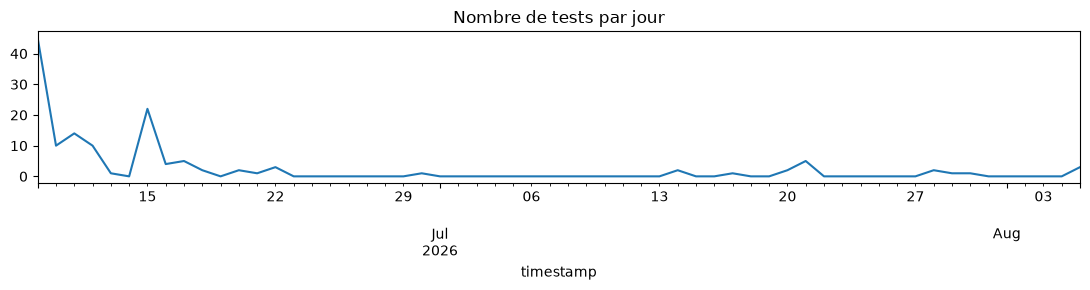

In [8]:
daily = df.set_index('timestamp').resample('D').size()
daily.plot(figsize=(11, 3), title='Nombre de tests par jour')
plt.tight_layout()
plt.show()